In [2]:
!pip install kagglehub -q

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write('KGAT_edd5203d79f7e096824a369623d38b12')
os.chmod('/root/.kaggle/access_token', 0o600)
print("Done!")

Done!


In [4]:
import importlib
import kagglehub
importlib.reload(kagglehub)

path = kagglehub.competition_download('rossmann-store-sales')
print("Path:", path)

100%|██████████| 6.99M/6.99M [00:00<00:00, 66.4MB/s]

Extracting files...


Path: /root/.cache/kagglehub/competitions/rossmann-store-sales


In [5]:
import os
path = '/root/.cache/kagglehub/competitions/rossmann-store-sales'
print(os.listdir(path))

['sample_submission.csv', 'test.csv', 'train.csv', 'store.csv']


In [6]:
import pandas as pd

df = pd.read_csv(f'{path}/train.csv', low_memory=False)
store = pd.read_csv(f'{path}/store.csv')

print("Train shape:", df.shape)
print("Store shape:", store.shape)
print(df.head(3))

Train shape: (1017209, 9)
Store shape: (1115, 10)
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  


In [7]:
print("=== DATASET OVERVIEW ===")
print(f"Train Records: {df.shape[0]:,}")
print(f"Train Features: {df.shape[1]}")
print(f"Store Records: {store.shape[0]:,}")
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

=== DATASET OVERVIEW ===
Train Records: 1,017,209
Train Features: 9
Store Records: 1,115

Column Names:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

First 3 rows:
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  


In [8]:
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== DATA TYPES ===
Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

=== MISSING VALUES ===
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Merge train + store
df_merged = df.merge(store, on='Store', how='left')

# Only open days
df_open = df_merged[df_merged['Open'] == 1].copy()

print("Merged shape:", df_merged.shape)
print("Open days only:", df_open.shape)

Merged shape: (1017209, 18)
Open days only: (844392, 18)


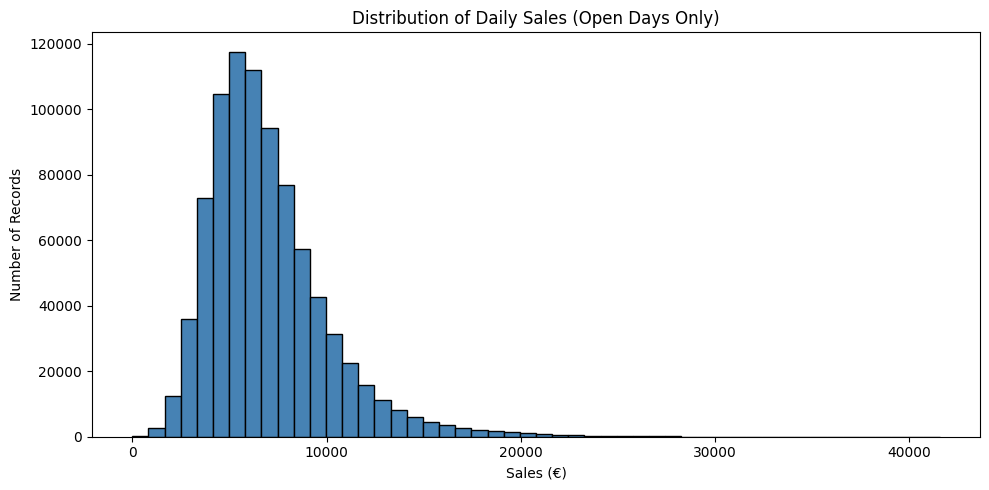

Plot 1 saved!


In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df_open['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Daily Sales (Open Days Only)')
plt.xlabel('Sales (€)')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.savefig('plot1_sales_distribution.png')
plt.show()
print("Plot 1 saved!")

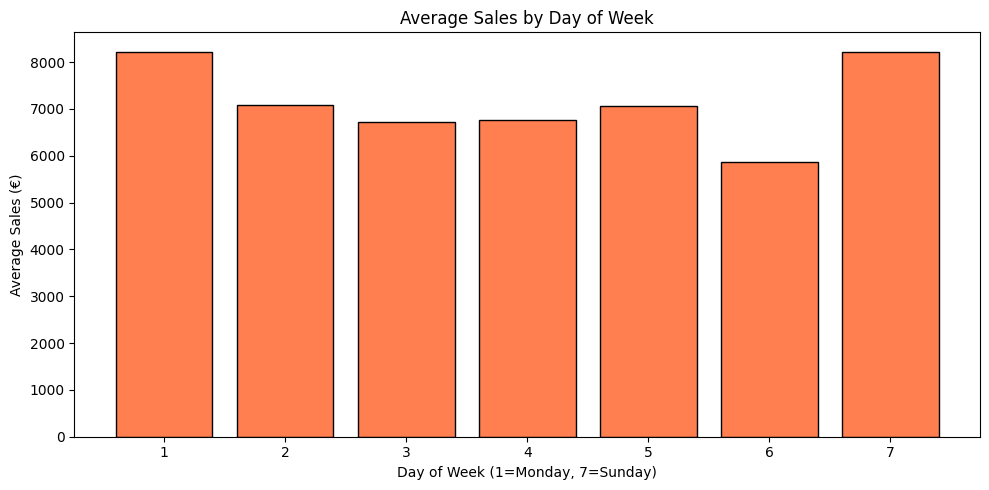

Plot 2 saved!


In [11]:
plt.figure(figsize=(10, 5))
day_sales = df_open.groupby('DayOfWeek')['Sales'].mean()
plt.bar(day_sales.index, day_sales.values, color='coral', edgecolor='black')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week (1=Monday, 7=Sunday)')
plt.ylabel('Average Sales (€)')
plt.xticks([1,2,3,4,5,6,7])
plt.tight_layout()
plt.savefig('plot2_sales_by_day.png')
plt.show()
print("Plot 2 saved!")

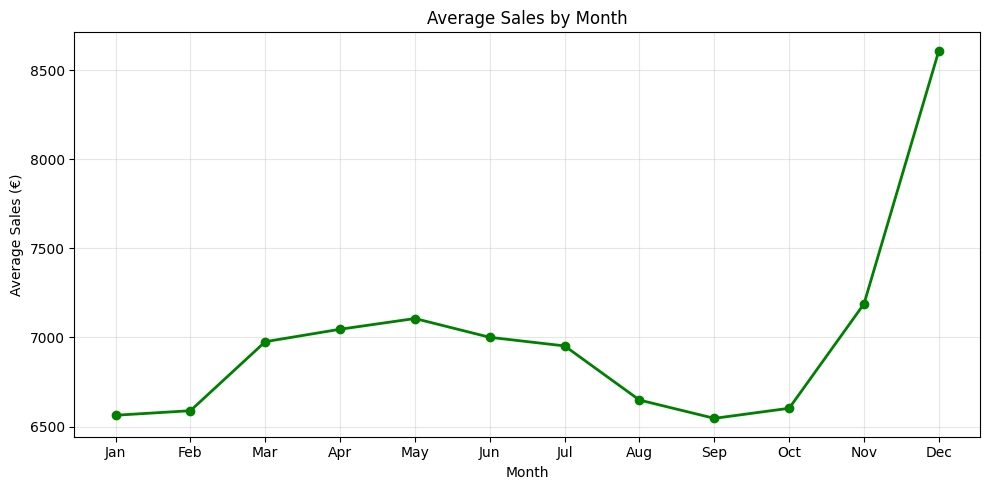

Plot 3 saved!


In [12]:
df_open['Date'] = pd.to_datetime(df_open['Date'])
df_open['Month'] = df_open['Date'].dt.month

plt.figure(figsize=(10, 5))
monthly_sales = df_open.groupby('Month')['Sales'].mean()
plt.plot(monthly_sales.index, monthly_sales.values,
         marker='o', color='green', linewidth=2)
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales (€)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot3_monthly_trend.png')
plt.show()
print("Plot 3 saved!")

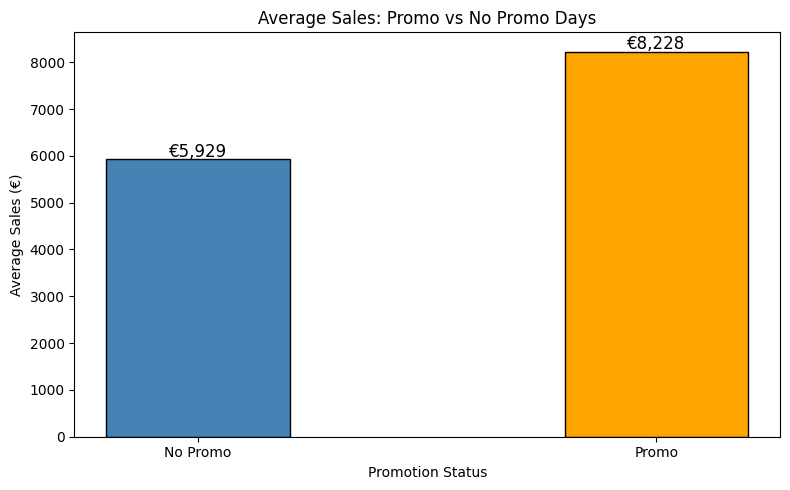

Plot 4 saved!


In [13]:
plt.figure(figsize=(8, 5))
promo_sales = df_open.groupby('Promo')['Sales'].mean()
bars = plt.bar(['No Promo', 'Promo'], promo_sales.values,
               color=['steelblue', 'orange'], edgecolor='black', width=0.4)

# Add value labels on top of bars
for bar, val in zip(bars, promo_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'€{val:,.0f}',
             ha='center', fontsize=12)

plt.title('Average Sales: Promo vs No Promo Days')
plt.xlabel('Promotion Status')
plt.ylabel('Average Sales (€)')
plt.tight_layout()
plt.savefig('plot4_promo_sales.png')
plt.show()
print("Plot 4 saved!")

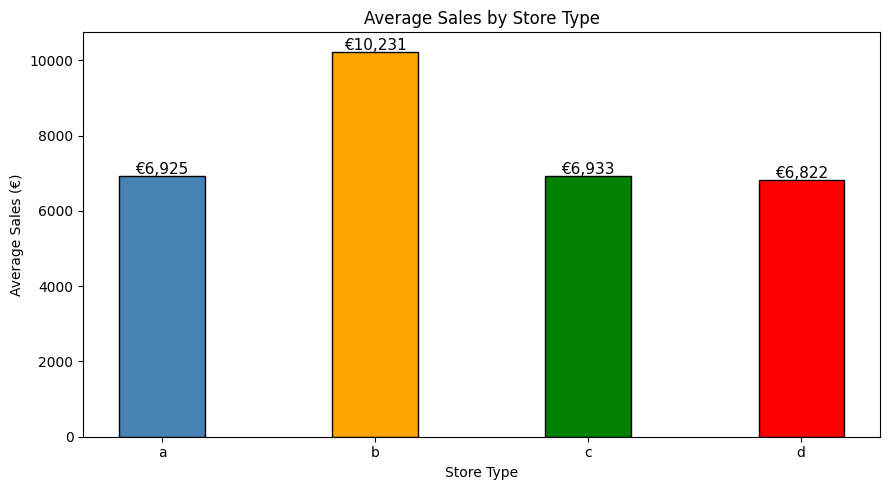

Plot 5 saved!


In [14]:
plt.figure(figsize=(9, 5))
storetype_sales = df_open.groupby('StoreType')['Sales'].mean()
bars = plt.bar(storetype_sales.index, storetype_sales.values,
               color=['steelblue','orange','green','red'],
               edgecolor='black', width=0.4)

for bar, val in zip(bars, storetype_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'€{val:,.0f}',
             ha='center', fontsize=11)

plt.title('Average Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Sales (€)')
plt.tight_layout()
plt.savefig('plot5_storetype_sales.png')
plt.show()
print("Plot 5 saved!")

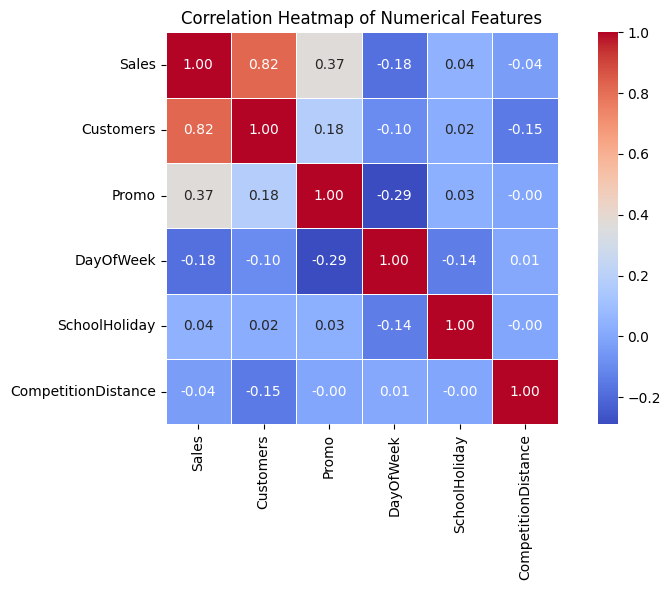

Plot 6 saved!


In [15]:
# Select only numerical columns
num_cols = ['Sales', 'Customers', 'Promo', 'DayOfWeek',
            'SchoolHoliday', 'CompetitionDistance']

corr_matrix = df_open[num_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('plot6_correlation_heatmap.png')
plt.show()
print("Plot 6 saved!")

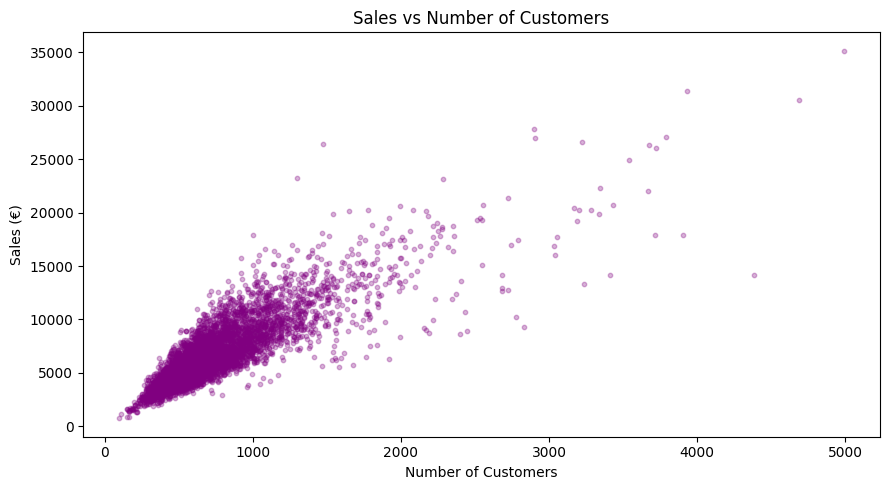

Plot 7 saved!


In [16]:
plt.figure(figsize=(9, 5))
# Sample 5000 points to avoid overcrowding
sample = df_open.sample(5000, random_state=42)
plt.scatter(sample['Customers'], sample['Sales'],
            alpha=0.3, color='purple', s=10)
plt.title('Sales vs Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Sales (€)')
plt.tight_layout()
plt.savefig('plot7_sales_vs_customers.png')
plt.show()
print("Plot 7 saved!")

In [17]:
# Step 1: Remove closed store days & zero sales
df_clean = df_merged[df_merged['Open'] == 1].copy()
df_clean = df_clean[df_clean['Sales'] > 0].copy()

# Step 2: Parse date and extract time features
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['WeekOfYear'] = df_clean['Date'].dt.isocalendar().week.astype(int)

print("After removing closed days:", df_clean.shape)
print("Missing values before fix:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

After removing closed days: (844338, 21)
Missing values before fix:
CompetitionDistance            2186
CompetitionOpenSinceMonth    268600
CompetitionOpenSinceYear     268600
Promo2SinceWeek              423292
Promo2SinceYear              423292
PromoInterval                423292
dtype: int64


In [ ]:
# Step 1: Remove closed store days & zero sales
df_clean = df_merged[df_merged['Open'] == 1].copy()
df_clean = df_clean[df_clean['Sales'] > 0].copy()

# Step 2: Parse date and extract time features
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['WeekOfYear'] = df_clean['Date'].dt.isocalendar().week.astype(int)

print("After removing closed days:", df_clean.shape)
print("Missing values before fix:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

After removing closed days: (844338, 21)
Missing values before fix:
CompetitionDistance            2186
CompetitionOpenSinceMonth    268600
CompetitionOpenSinceYear     268600
Promo2SinceWeek              423292
Promo2SinceYear              423292
PromoInterval                423292
dtype: int64


In [18]:
# Step 3: Handle missing values

# CompetitionDistance - fill with median (numerical)
df_clean['CompetitionDistance'].fillna(df_clean['CompetitionDistance'].median(), inplace=True)

# CompetitionOpenSince - fill with 0 (unknown = no competitor)
df_clean['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
df_clean['CompetitionOpenSinceYear'].fillna(0, inplace=True)

# Promo2 columns - fill with 0 (not participating)
df_clean['Promo2SinceWeek'].fillna(0, inplace=True)
df_clean['Promo2SinceYear'].fillna(0, inplace=True)
df_clean['PromoInterval'].fillna('None', inplace=True)

# Verify
print("Missing values after fix:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("\nAll missing values handled!" if df_clean.isnull().sum().sum() == 0 else "Still some missing!")

/tmp/ipykernel_10958/3563462740.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['CompetitionDistance'].fillna(df_clean['CompetitionDistance'].median(), inplace=True)
/tmp/ipykernel_10958/3563462740.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when d

Missing values after fix:
Series([], dtype: int64)

All missing values handled!


In [19]:
# Step 4: Outlier capping at 99th percentile
cap_value = df_clean['Sales'].quantile(0.99)
df_clean['Sales'] = df_clean['Sales'].clip(upper=cap_value)
print(f"Sales capped at 99th percentile: €{cap_value:,.0f}")

# Step 5: Encode categorical columns
df_clean['StoreType'] = df_clean['StoreType'].map({'a':0, 'b':1, 'c':2, 'd':3})
df_clean['Assortment'] = df_clean['Assortment'].map({'a':0, 'b':1, 'c':2})
df_clean['StateHoliday'] = df_clean['StateHoliday'].map({'0':0, 0:0, 'a':1, 'b':2, 'c':3})
df_clean['PromoInterval'] = df_clean['PromoInterval'].map({
    'None':0, 'Jan,Apr,Jul,Oct':1,
    'Feb,May,Aug,Nov':2, 'Mar,Jun,Sept,Dec':3})

print("\nEncoding done!")
print(df_clean[['StoreType','Assortment','StateHoliday','PromoInterval']].head(3))

Sales capped at 99th percentile: €17,789

Encoding done!
   StoreType  Assortment  StateHoliday  PromoInterval
0          2           0             0              0
1          0           0             0              1
2          0           0             0              1


In [20]:
# Step 6: Feature Engineering - extract useful numeric features
df_clean['CompetitionOpenMonths'] = (
    (df_clean['Year'] - df_clean['CompetitionOpenSinceYear']) * 12 +
    (df_clean['Month'] - df_clean['CompetitionOpenSinceMonth'])
)
df_clean['CompetitionOpenMonths'] = df_clean['CompetitionOpenMonths'].clip(lower=0)

# Step 7: Select final features for modelling
feature_cols = [
    'Store', 'DayOfWeek', 'Promo', 'SchoolHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance',
    'Promo2', 'Month', 'Year', 'WeekOfYear',
    'StateHoliday', 'PromoInterval', 'CompetitionOpenMonths'
]

df_model = df_clean[feature_cols + ['Sales']].copy()
df_model = df_model.dropna()

print("Final dataset shape:", df_model.shape)
print("\nFeature columns:", feature_cols)
print("\nSample data:")
print(df_model.head(3))

Final dataset shape: (844338, 15)

Feature columns: ['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'Month', 'Year', 'WeekOfYear', 'StateHoliday', 'PromoInterval', 'CompetitionOpenMonths']

Sample data:
   Store  DayOfWeek  Promo  SchoolHoliday  StoreType  Assortment  \
0      1          5      1              1          2           0   
1      2          5      1              1          0           0   
2      3          5      1              1          0           0   

   CompetitionDistance  Promo2  Month  Year  WeekOfYear  StateHoliday  \
0               1270.0       0      7  2015          31             0   
1                570.0       1      7  2015          31             0   
2              14130.0       1      7  2015          31             0   

   PromoInterval  CompetitionOpenMonths  Sales  
0              0                   82.0   5263  
1              1                   92.0   6064  
2              1       

In [21]:
from sklearn.model_selection import train_test_split

X = df_model[feature_cols]
y = df_model['Sales']

# Chronological split - sort by index (date order preserved)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print(f"\nTrain records: {len(X_train):,}")
print(f"Test records:  {len(X_test):,}")

Train size: (675470, 14)
Test size: (168868, 14)

Train records: 675,470
Test records:  168,868


In [22]:
import numpy as np

class LinearRegressionScratch:
    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # Convert to numpy arrays
        X_np = np.array(X)
        y_np = np.array(y)

        # Add bias column (column of 1s)
        X_b = np.column_stack([np.ones(len(X_np)), X_np])

        # Normal Equation: w = (X^T X)^-1 X^T y
        print("Fitting Linear Regression using Normal Equation...")
        XtX = X_b.T @ X_b
        Xty = X_b.T @ y_np
        params = np.linalg.lstsq(XtX, Xty, rcond=None)[0]

        self.bias = params[0]
        self.weights = params[1:]
        print("Training complete!")

    def predict(self, X):
        X_np = np.array(X)
        return X_np @ self.weights + self.bias

# Train model
lr_model = LinearRegressionScratch()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)
print("\nSample predictions:", y_pred_lr[:5])
print("Actual values:     ", y_test.values[:5])

Fitting Linear Regression using Normal Equation...
Training complete!

Sample predictions: [7436.56357086 8196.68042802 8488.22878491 8124.55790289 7997.89691828]
Actual values:      [ 4513  5749 10201 15589  7227]


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test.values - y_pred_lr) / y_test.values)) * 100

print("=" * 40)
print("  LINEAR REGRESSION (Baseline) RESULTS")
print("=" * 40)
print(f"  MAE  : €{mae_lr:,.2f}")
print(f"  RMSE : €{rmse_lr:,.2f}")
print(f"  R²   : {r2_lr:.4f}")
print(f"  MAPE : {mape_lr:.2f}%")
print("=" * 40)

  LINEAR REGRESSION (Baseline) RESULTS
  MAE  : €2,012.76
  RMSE : €2,638.92
  R²   : 0.1575
  MAPE : 36.59%


In [24]:
class DecisionTreeScratch:
    def __init__(self, max_depth=10, min_samples_split=50):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _mse(self, y):
        if len(y) == 0:
            return 0
        return np.var(y) * len(y)

    def _best_split(self, X, y):
        best_mse = float('inf')
        best_feat = None
        best_thresh = None

        n_features = X.shape[1]
        for feat in range(n_features):
            thresholds = np.percentile(X[:, feat], [25, 50, 75])
            for thresh in thresholds:
                left_mask = X[:, feat] <= thresh
                right_mask = ~left_mask
                if left_mask.sum() < self.min_samples_split or right_mask.sum() < self.min_samples_split:
                    continue
                mse = self._mse(y[left_mask]) + self._mse(y[right_mask])
                if mse < best_mse:
                    best_mse = mse
                    best_feat = feat
                    best_thresh = thresh
        return best_feat, best_thresh

    def _build(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return {'leaf': True, 'value': np.mean(y)}
        feat, thresh = self._best_split(X, y)
        if feat is None:
            return {'leaf': True, 'value': np.mean(y)}
        left_mask = X[:, feat] <= thresh
        right_mask = ~left_mask
        return {
            'leaf': False,
            'feat': feat,
            'thresh': thresh,
            'left': self._build(X[left_mask], y[left_mask], depth+1),
            'right': self._build(X[right_mask], y[right_mask], depth+1)
        }

    def fit(self, X, y):
        print("Training Decision Tree... (takes 1-2 mins)")
        self.tree = self._build(np.array(X), np.array(y), 0)
        print("Training complete!")

    def _predict_one(self, x, node):
        if node['leaf']:
            return node['value']
        if x[node['feat']] <= node['thresh']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])

    def predict(self, X):
        X_np = np.array(X)
        return np.array([self._predict_one(row, self.tree) for row in X_np])

# Train - using subset for speed
print("Training on 100,000 samples for speed...")
X_train_sub = X_train.iloc[:100000]
y_train_sub = y_train.iloc[:100000]

dt_model = DecisionTreeScratch(max_depth=10, min_samples_split=50)
dt_model.fit(X_train_sub, y_train_sub)

Training on 100,000 samples for speed...
Training Decision Tree... (takes 1-2 mins)
Training complete!


In [25]:
# Predict on test set (subset for speed)
print("Predicting... (takes 1-2 mins)")
X_test_sub = X_test.iloc[:20000]
y_test_sub = y_test.iloc[:20000]

y_pred_dt = dt_model.predict(X_test_sub)
print("Predictions done!")

# Metrics
mae_dt  = mean_absolute_error(y_test_sub, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test_sub, y_pred_dt))
r2_dt   = r2_score(y_test_sub, y_pred_dt)
mape_dt = np.mean(np.abs((y_test_sub.values - y_pred_dt) / y_test_sub.values)) * 100

print("\n" + "=" * 40)
print("   DECISION TREE RESULTS")
print("=" * 40)
print(f"  MAE  : €{mae_dt:,.2f}")
print(f"  RMSE : €{rmse_dt:,.2f}")
print(f"  R²   : {r2_dt:.4f}")
print(f"  MAPE : {mape_dt:.2f}%")
print("=" * 40)

Predicting... (takes 1-2 mins)
Predictions done!

   DECISION TREE RESULTS
  MAE  : €1,780.32
  RMSE : €2,326.24
  R²   : 0.3133
  MAPE : 31.15%


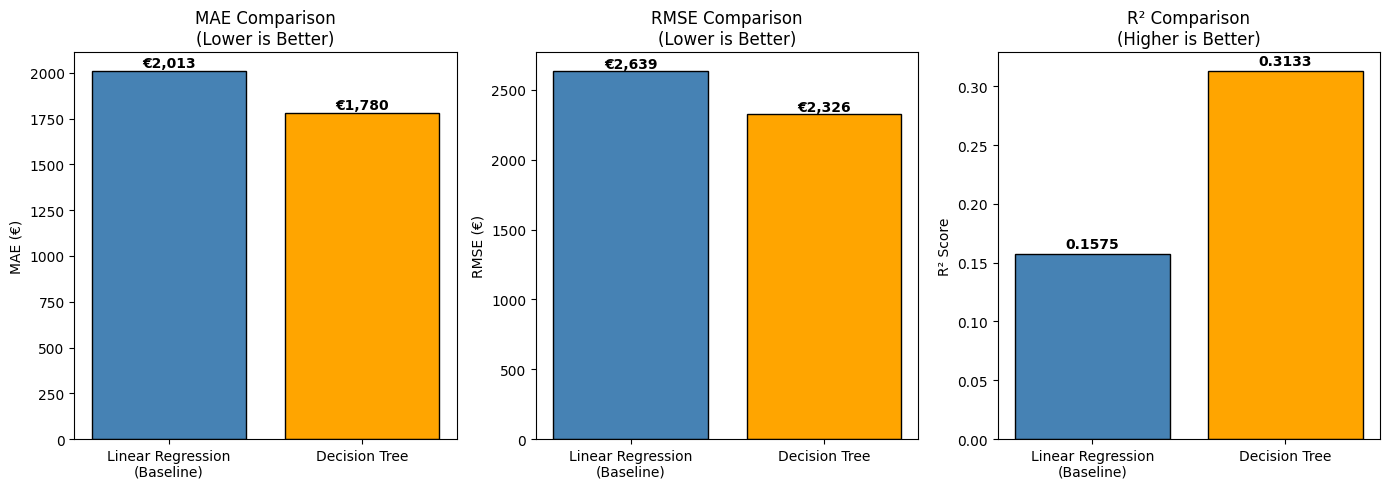

Comparison chart saved!


In [26]:
# Visual comparison of both models
models = ['Linear Regression\n(Baseline)', 'Decision Tree']
mae_vals  = [mae_lr, mae_dt]
rmse_vals = [rmse_lr, rmse_dt]
r2_vals   = [r2_lr, r2_dt]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# MAE
axes[0].bar(models, mae_vals, color=['steelblue', 'orange'], edgecolor='black')
axes[0].set_title('MAE Comparison\n(Lower is Better)')
axes[0].set_ylabel('MAE (€)')
for i, v in enumerate(mae_vals):
    axes[0].text(i, v + 20, f'€{v:,.0f}', ha='center', fontweight='bold')

# RMSE
axes[1].bar(models, rmse_vals, color=['steelblue', 'orange'], edgecolor='black')
axes[1].set_title('RMSE Comparison\n(Lower is Better)')
axes[1].set_ylabel('RMSE (€)')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 20, f'€{v:,.0f}', ha='center', fontweight='bold')

# R2
axes[2].bar(models, r2_vals, color=['steelblue', 'orange'], edgecolor='black')
axes[2].set_title('R² Comparison\n(Higher is Better)')
axes[2].set_ylabel('R² Score')
for i, v in enumerate(r2_vals):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot8_model_comparison.png')
plt.show()
print("Comparison chart saved!")

      ERROR ANALYSIS
Mean Error    : €1,780.32
Median Error  : €1,449.30
Max Error     : €12,499.92
% within €500 : 18.8%
% within €1000: 36.0%
% within €2000: 65.0%


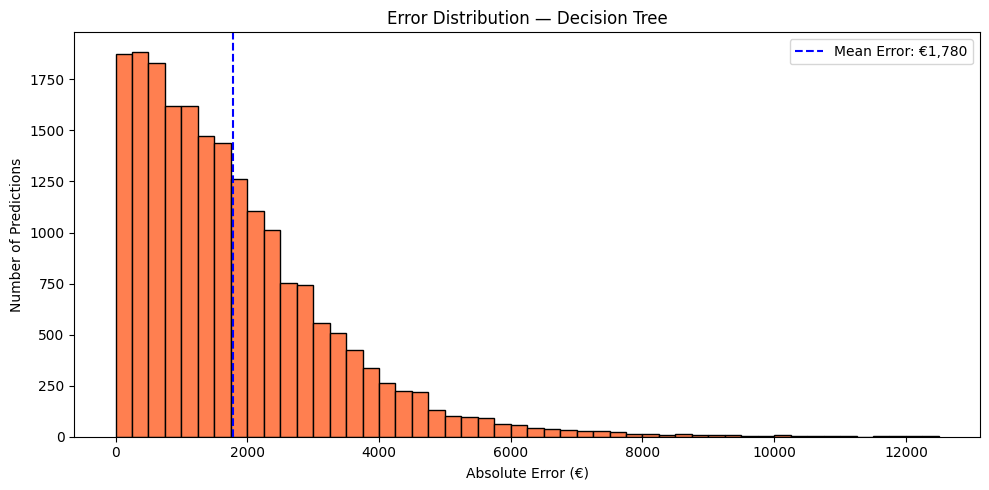

Error analysis done!


In [27]:
# Error Analysis
errors = np.abs(y_test_sub.values - y_pred_dt)
error_pct = (errors / y_test_sub.values) * 100

print("=" * 40)
print("      ERROR ANALYSIS")
print("=" * 40)
print(f"Mean Error    : €{np.mean(errors):,.2f}")
print(f"Median Error  : €{np.median(errors):,.2f}")
print(f"Max Error     : €{np.max(errors):,.2f}")
print(f"% within €500 : {(errors < 500).mean()*100:.1f}%")
print(f"% within €1000: {(errors < 1000).mean()*100:.1f}%")
print(f"% within €2000: {(errors < 2000).mean()*100:.1f}%")

# Error distribution plot
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, color='coral', edgecolor='black')
plt.title('Error Distribution — Decision Tree')
plt.xlabel('Absolute Error (€)')
plt.ylabel('Number of Predictions')
plt.axvline(np.mean(errors), color='blue',
            linestyle='--', label=f'Mean Error: €{np.mean(errors):,.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('plot9_error_distribution.png')
plt.show()
print("Error analysis done!")